In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import GridSearchCV

In [2]:
df_main = pd.read_csv('../data/cleaned/analysis_data.csv')
fuel_subsidy_usd_col = 'fuel_subsidy_usd_million'
fuel_subsidy_pct_col = 'fuel_subsidy_gdp'

In [3]:
country_subsidy_profiles = (df_main
                               .groupby('country')
                               .agg({
                                   'fuel_subsidy_gdp': 'mean',
                                   'fuel_subsidy_usd_million': 'sum',
                                   'gdp': 'mean'
                               })
                               .reset_index())

In [4]:
country_subsidy_profiles

,country,fuel_subsidy_gdp,fuel_subsidy_usd_million,gdp
0,Afghanistan,0.102286,735.338963,4.078431e+10
1,Albania,0.337725,1317.278909,2.406177e+10
2,Algeria,3.349375,237631.818445,4.030311e+11
3,Angola,1.219099,24663.434871,9.979623e+10
4,Argentina,1.516023,163665.204087,6.971394e+11
...,...,...,...,...
164,Venezuela,5.806504,254585.484207,3.645908e+11
165,Vietnam,0.610775,53312.005667,4.317543e+11
166,Yemen,0.662875,8839.295788,8.032479e+10
167,Zambia,1.609929,10878.565213,3.895613e+10


## Fuel Subsidies as a DiD Interaction

A carbon tax and a fuel subsidy move the effective fossil-fuel price in opposite directions, so large subsidies should blunt the tax. We test `post_carbon_tax x fuel_subsidy_gdp` in the DiD with country + year fixed effects and clustered SEs, and trace the implied tax effect across subsidy levels.

In [5]:
import statsmodels.formula.api as smf

# Fuel subsidies as a moderator of the CLEAN tax / ETS indicators (post_carbon_tax conflates the two).
df = pd.read_csv('../data/cleaned/final_analysis_data.csv')
y = 'co2_per_capita_future_trend'
base_controls = ('log_gdp + log_population + trade_openness '
                 '+ natural_resource_rents_per_gdp + fossil_pct_filled')
need = [y, 'has_tax', 'has_ets', 'fuel_subsidy_gdp', 'log_gdp', 'log_population',
        'trade_openness', 'natural_resource_rents_per_gdp', 'fossil_pct_filled']
d = df.dropna(subset=need)
print(f"Subsidy subsample: {len(d)} obs, tax={int(d['has_tax'].sum())}, ETS={int(d['has_ets'].sum())}\n")

def fit(formula):
    return smf.ols(formula, data=d).fit(cov_type='cluster', cov_kwds={'groups': d['country']})

# subsidy as a plain control, then interacted with each clean treatment
m0 = fit(f"{y} ~ has_tax + has_ets + fuel_subsidy_gdp + {base_controls} + C(year) + C(country)")
print(f"baseline has_tax: {m0.params['has_tax']:+.4f} (p={m0.pvalues['has_tax']:.3f})")
print(f"baseline has_ets: {m0.params['has_ets']:+.4f} (p={m0.pvalues['has_ets']:.3f})\n")

m1 = fit(f"{y} ~ has_tax * fuel_subsidy_gdp + has_ets + {base_controls} + C(year) + C(country)")
print("Tax x subsidy:")
for term in ['has_tax', 'fuel_subsidy_gdp', 'has_tax:fuel_subsidy_gdp']:
    print(f"  {term:28} {m1.params[term]:+.4f}  (SE {m1.bse[term]:.4f}, p={m1.pvalues[term]:.3f})")
for q in [0.1, 0.5, 0.9]:
    s = d['fuel_subsidy_gdp'].quantile(q)
    eff = m1.params['has_tax'] + m1.params['has_tax:fuel_subsidy_gdp'] * s
    print(f"  implied tax effect at subsidy p{int(q*100)} ({s:.2f}% GDP): {eff:+.4f}")

# symmetry: does the subsidy also blunt the ETS?
m2 = fit(f"{y} ~ has_ets * fuel_subsidy_gdp + has_tax + {base_controls} + C(year) + C(country)")
print("\nETS x subsidy (symmetry check):")
for term in ['has_ets', 'has_ets:fuel_subsidy_gdp']:
    print(f"  {term:28} {m2.params[term]:+.4f}  (SE {m2.bse[term]:.4f}, p={m2.pvalues[term]:.3f})")

Subsidy subsample: 1781 obs, tax=202, ETS=339



baseline has_tax: -0.0480 (p=0.165)
baseline has_ets: +0.1189 (p=0.063)



Tax x subsidy:
  has_tax                      -0.0973  (SE 0.0527, p=0.065)
  fuel_subsidy_gdp             -0.0147  (SE 0.0144, p=0.307)
  has_tax:fuel_subsidy_gdp     +0.0842  (SE 0.0590, p=0.154)
  implied tax effect at subsidy p10 (0.00% GDP): -0.0973
  implied tax effect at subsidy p50 (0.29% GDP): -0.0728
  implied tax effect at subsidy p90 (2.04% GDP): +0.0740



ETS x subsidy (symmetry check):
  has_ets                      +0.0767  (SE 0.0827, p=0.353)
  has_ets:fuel_subsidy_gdp     +0.0556  (SE 0.0854, p=0.515)


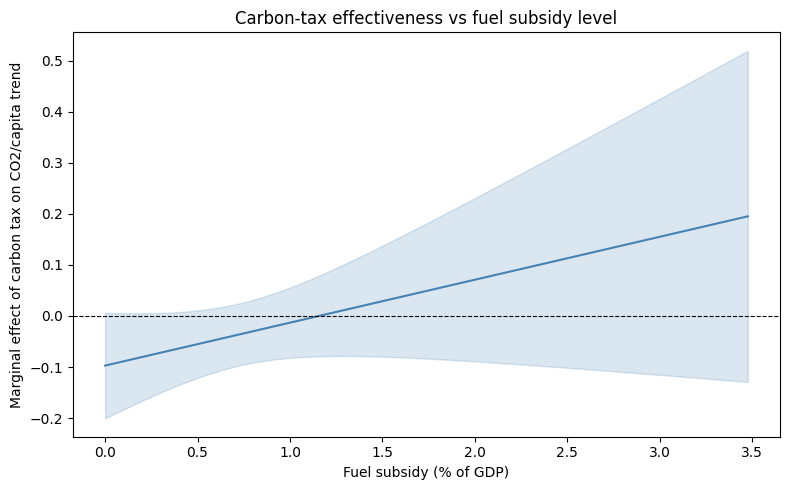

In [6]:
# Marginal effect of the carbon tax as a function of fuel subsidy level (delta-method CI)
sub = np.linspace(d['fuel_subsidy_gdp'].quantile(0.05), d['fuel_subsidy_gdp'].quantile(0.95), 50)
b, bi = m1.params['has_tax'], m1.params['has_tax:fuel_subsidy_gdp']
cov = m1.cov_params()
var = (cov.loc['has_tax', 'has_tax']
       + sub**2 * cov.loc['has_tax:fuel_subsidy_gdp', 'has_tax:fuel_subsidy_gdp']
       + 2 * sub * cov.loc['has_tax', 'has_tax:fuel_subsidy_gdp'])
eff = b + bi * sub
se = np.sqrt(var)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(sub, eff, color='steelblue')
ax.fill_between(sub, eff - 1.96 * se, eff + 1.96 * se, alpha=0.2, color='steelblue')
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Fuel subsidy (% of GDP)')
ax.set_ylabel('Marginal effect of carbon tax on CO2/capita trend')
ax.set_title('Carbon-tax effectiveness vs fuel subsidy level')
plt.tight_layout()
plt.savefig('../outputs/fuel_subsidy_interaction.png', dpi=150, bbox_inches='tight')
plt.show()

## Fuel subsidy interaction results (clean treatments)

Re-run with the de-conflated `has_tax` / `has_ets` (the earlier version used the conflated `post_carbon_tax`). In the subsidy subsample (1,781 obs; 202 tax, 339 ETS country-years):

- **Tax x subsidy = +0.084 (p=0.15)** — in the hypothesized direction: fuel subsidies blunt the carbon tax. At zero subsidy the tax effect is **-0.097 (p=0.065)**, eroding to roughly **+0.07** at high subsidy (~2% of GDP) and crossing zero near ~1.2% of GDP. Suggestive but **not significant** — the subsidy-data overlap is thin.
- **ETS x subsidy = +0.056 (p=0.52)** — null. The blunting is **tax-specific**, which is mechanistically sensible: consumer fuel subsidies directly offset the retail price signal a carbon tax raises, whereas the ETS bites upstream / power-sector emitters.
- **Caveat:** in this subsample `has_ets` flips positive (+0.12) — a selection artefact of the ~26-country subsidy overlap, not a real reversal. Read the subsample for the *interaction*, not for treatment levels.

**Verdict:** consistent with, but cannot establish, tax-subsidy antagonism. Resolving it needs broader time-varying subsidy coverage (a Phase 3 data lever), not a different estimator. With the clean-treatment re-run and symmetry check done, the Phase 2 fuel-subsidy question is closed as a documented, data-limited, suggestive-but-insignificant result.